In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import random
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch

# Add src to path
sys.path.append(os.path.abspath(".."))


from tqdm.notebook import tqdm

import diffmeshopt.opt2d.geometry as geometry
import diffmeshopt.opt2d.optimize as opt2d
import diffmeshopt.opt2d.vis as vis2d
from diffmeshopt.opt2d.loss import BiGaussianLoss
from diffmeshopt.opt2d.props import OptimizationProps, SamplingProps, TemplateProps

In [14]:
# 1. Load Data
data_path = Path("../data/2d_training_data.pkl")
if not data_path.exists():
    print(f"Data file {data_path} not found. Please run src/generate_2d_data.py first.")
else:
    print(f"Loading data from {data_path}...")
    data = joblib.load(data_path)
    image_np = -data["image"]
    contour_np = data["contour"]
    gt_contour_np = data["gt"]

Loading data from ../data/2d_training_data.pkl...


In [15]:
# 2. Smooth Contour
print("Smoothing initial contour...")
contour_smoothed, spline = geometry.smooth_contour(contour_np, num_points=1024, return_spline=True)

Smoothing initial contour...


In [16]:
sampling_props = SamplingProps(num_samples=51, sample_step=1.0, width=3, batch_size=256)
template_props = TemplateProps(peak_dist=4.5, width=0.5, num_samples=51)


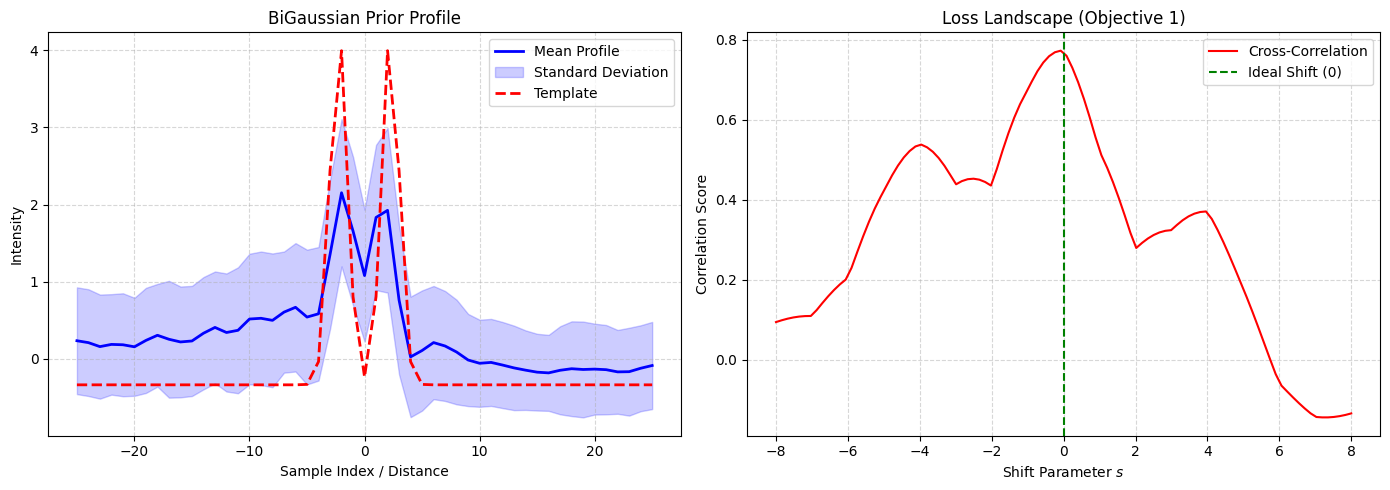

In [18]:
# Before smoothing
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    contour_np,
    sampling_props=sampling_props,
    template_props=template_props,
)

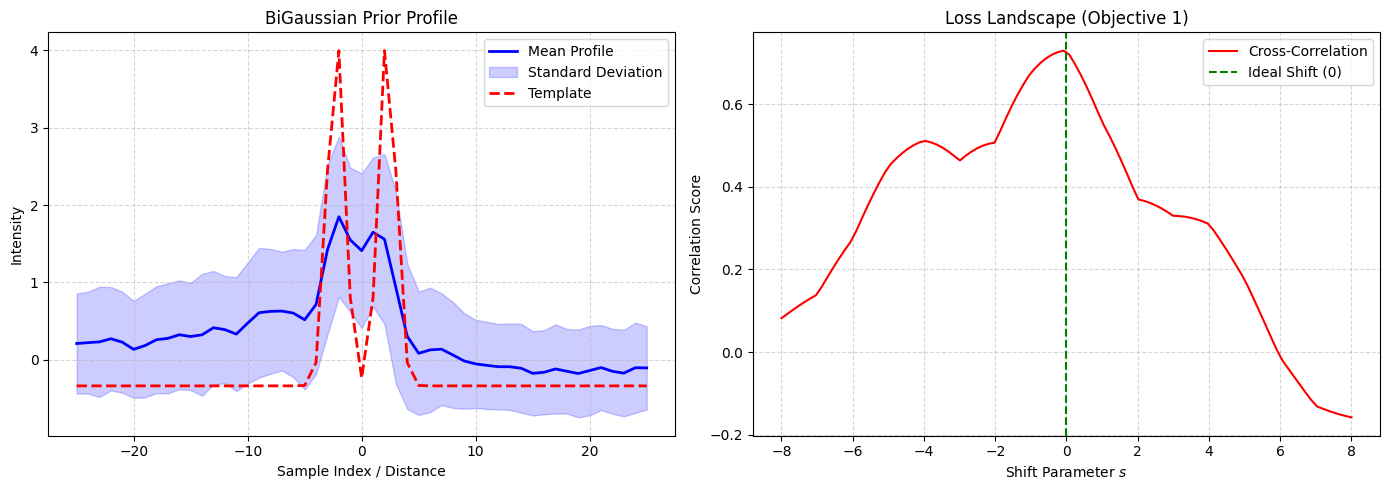

In [19]:
# After smoothing
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    contour_smoothed,
    sampling_props=sampling_props,
    template_props=template_props,
)

In [34]:
# First trying the global template

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

refiner = opt2d.ContourRefiner(
    image=image_np,
    initial_contour=contour_smoothed,
    optimization_props=OptimizationProps(
        w_edge=10, w_laplacian=20, w_sigma_reg=0.01, w_template_shape=0.5, lr=0.1
    ),
    template_props=template_props,
    sampling_props=sampling_props,
    laplacian_window_size=5,
    template_mode="global",
)
refiner.to(device)
print(f"Refiner initialized on {device}")

Refiner initialized on cuda


In [36]:
num_iterations = 500
history = []
print("Starting optimization...")
for _ in tqdm(range(num_iterations)):
    # 1. Optimization Step
    metrics = refiner.step()
    history.append(metrics)


print("Optimization finished.")

Starting optimization...


  0%|          | 0/500 [00:00<?, ?it/s]

Optimization finished.


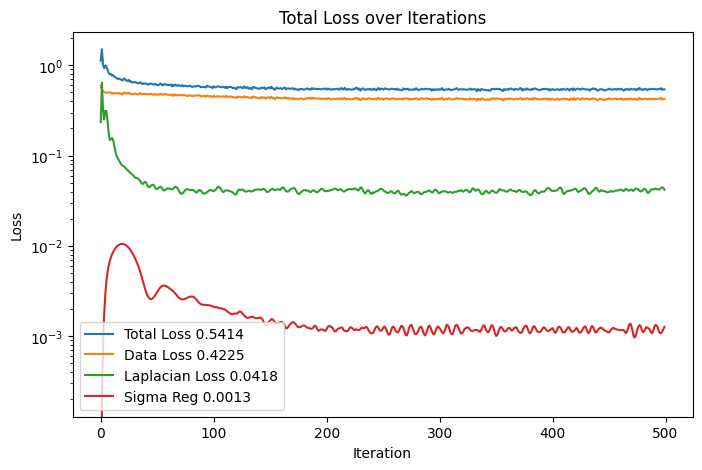

In [38]:
total_losses = [h["total_loss"] for h in history]
data_losses = [h["data_loss"] for h in history]
laplacian_losses = [h["laplacian_loss"] for h in history]
edge_losses = [h["edge_loss"] for h in history]
shape_losses = [h["shape_loss"] for h in history]
sigma_regs = [h["sigma_reg"] for h in history]

plt.figure(figsize=(8, 5))
plt.plot(total_losses, label=f"Total Loss {total_losses[-1]:.4f}")
plt.plot(data_losses, label=f"Data Loss {data_losses[-1]:.4f}")
plt.plot(laplacian_losses, label=f"Laplacian Loss {laplacian_losses[-1]:.4f}")

if refiner.template_model.mode == "global":
    plt.plot(edge_losses, label=f"Edge Loss {edge_losses[-1]:.4f}")
    plt.plot(shape_losses, label=f"Shape Loss {shape_losses[-1]:.4f}")
plt.plot(sigma_regs, label=f"Sigma Reg {sigma_regs[-1]:.4f}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Total Loss over Iterations")
plt.legend()
plt.show()

(20,)


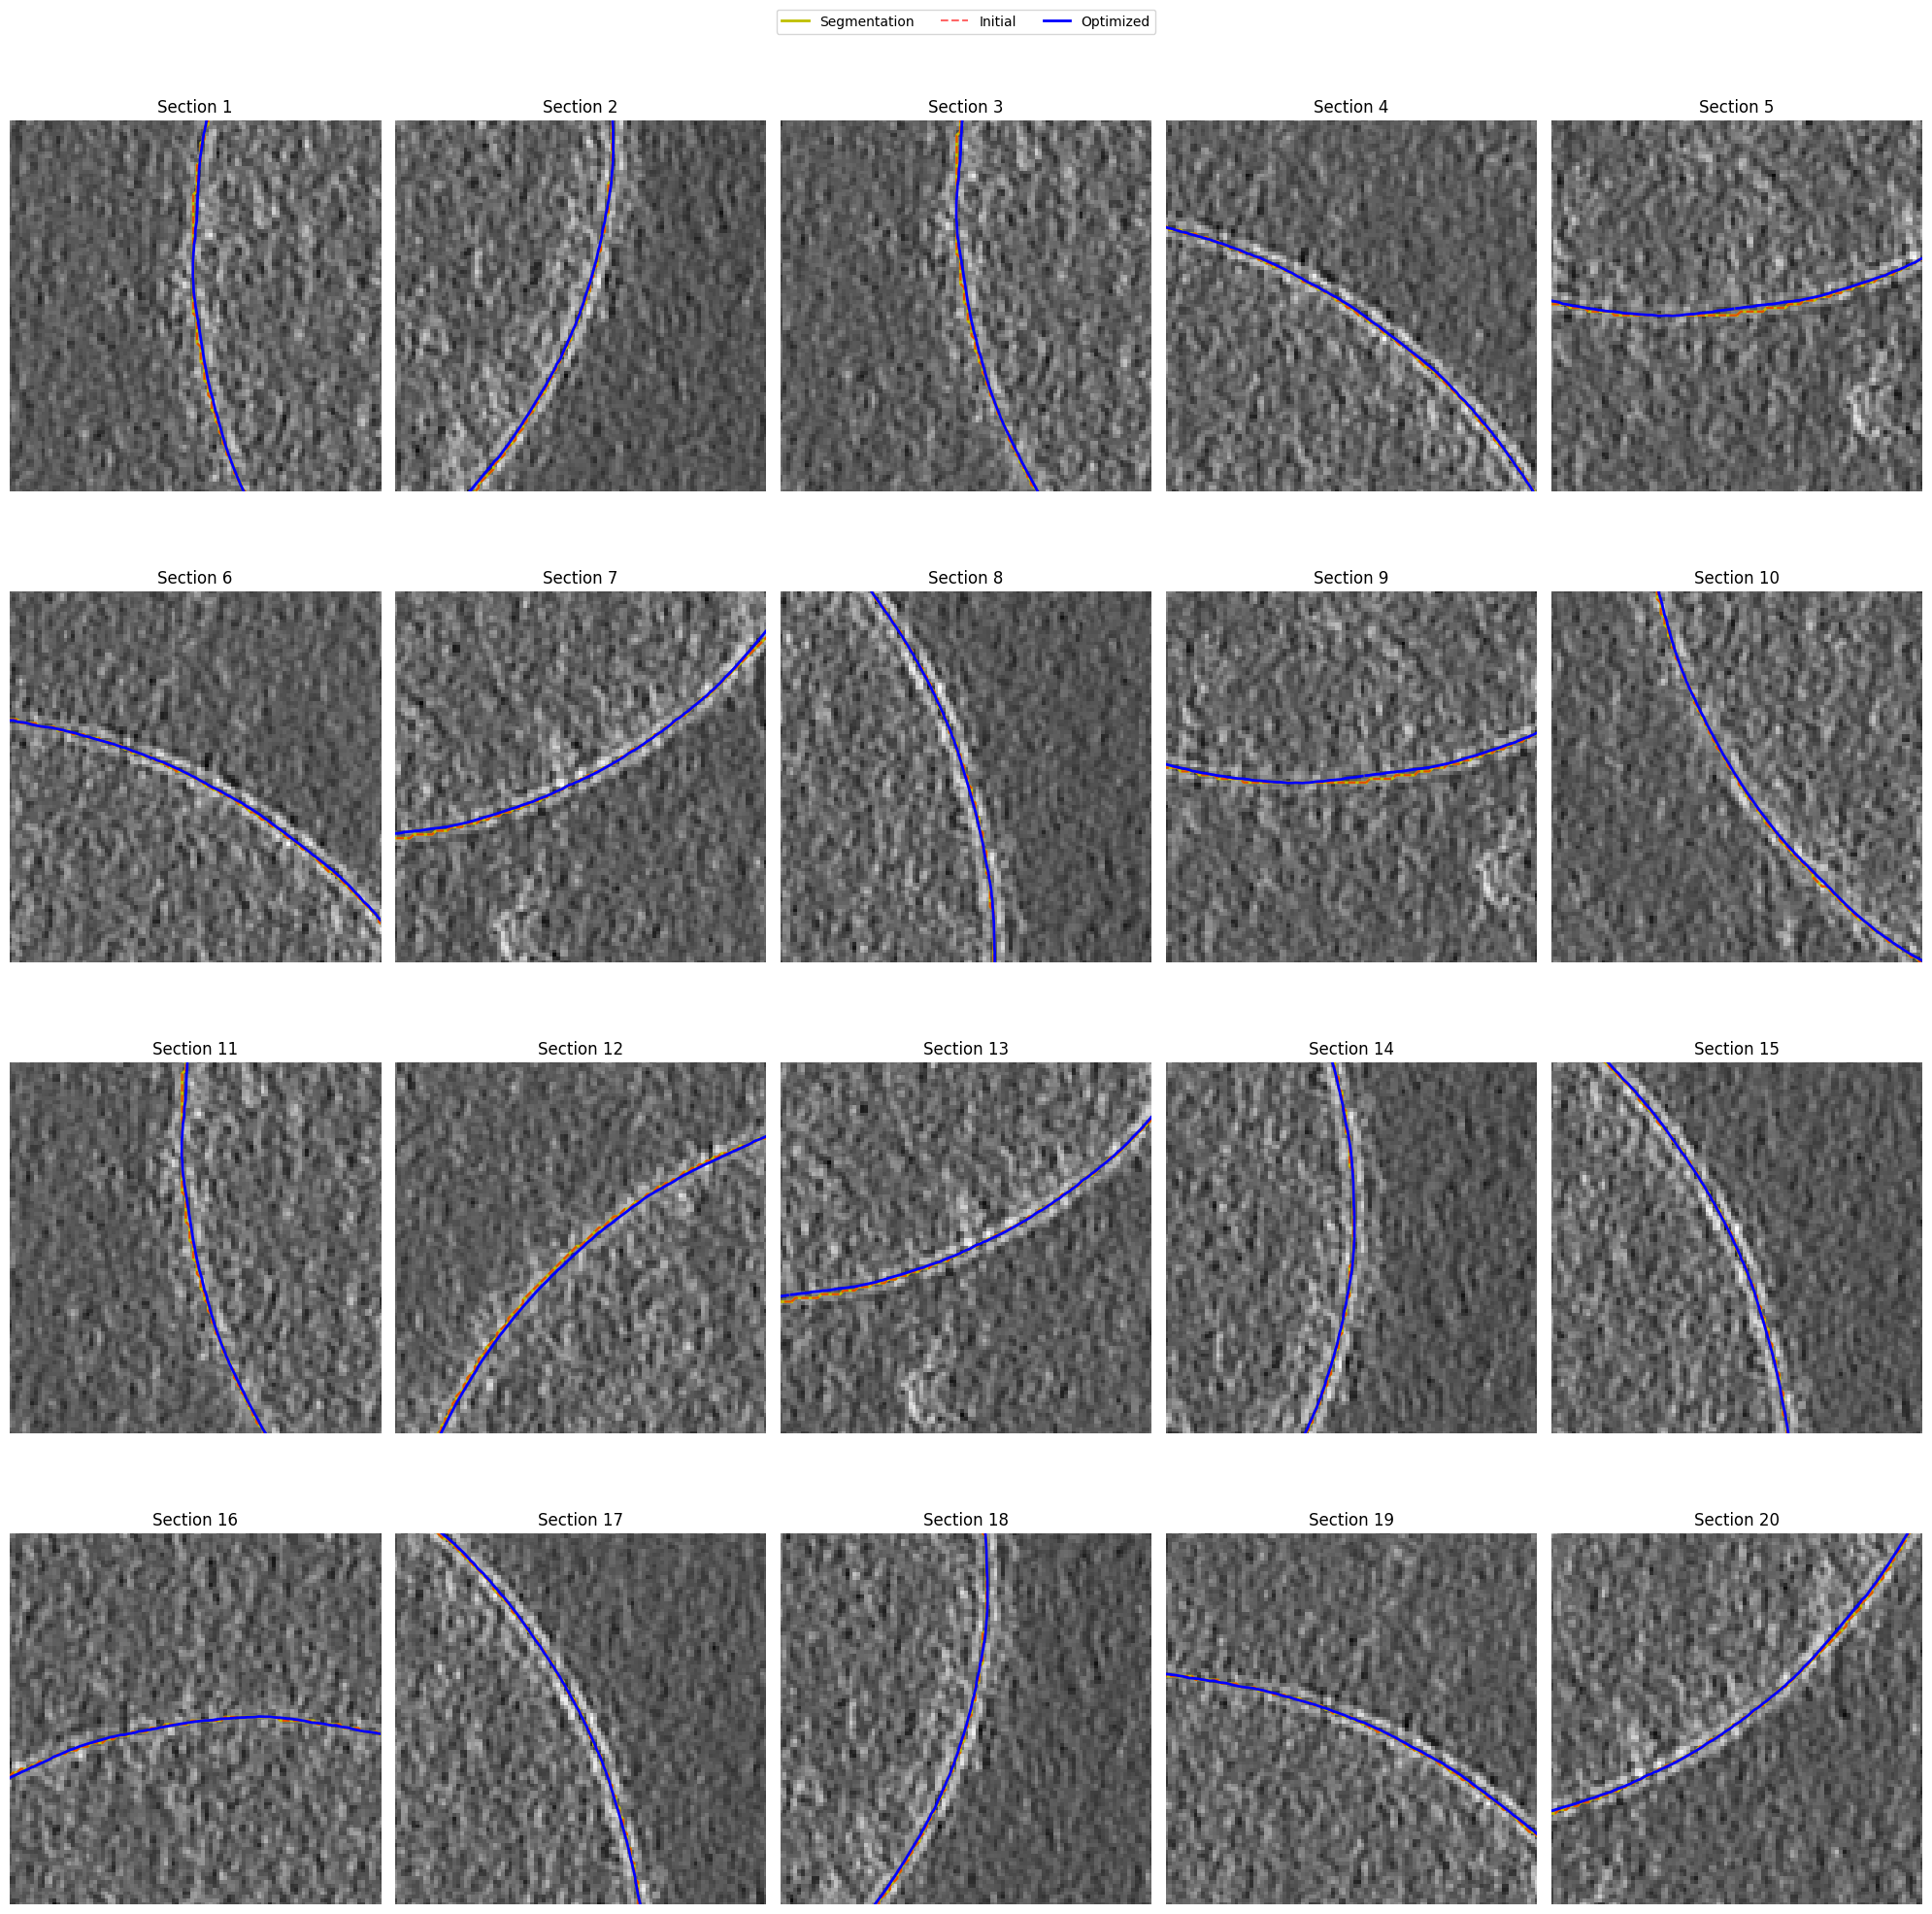

In [39]:
init_contour = contour_np

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

(20,)


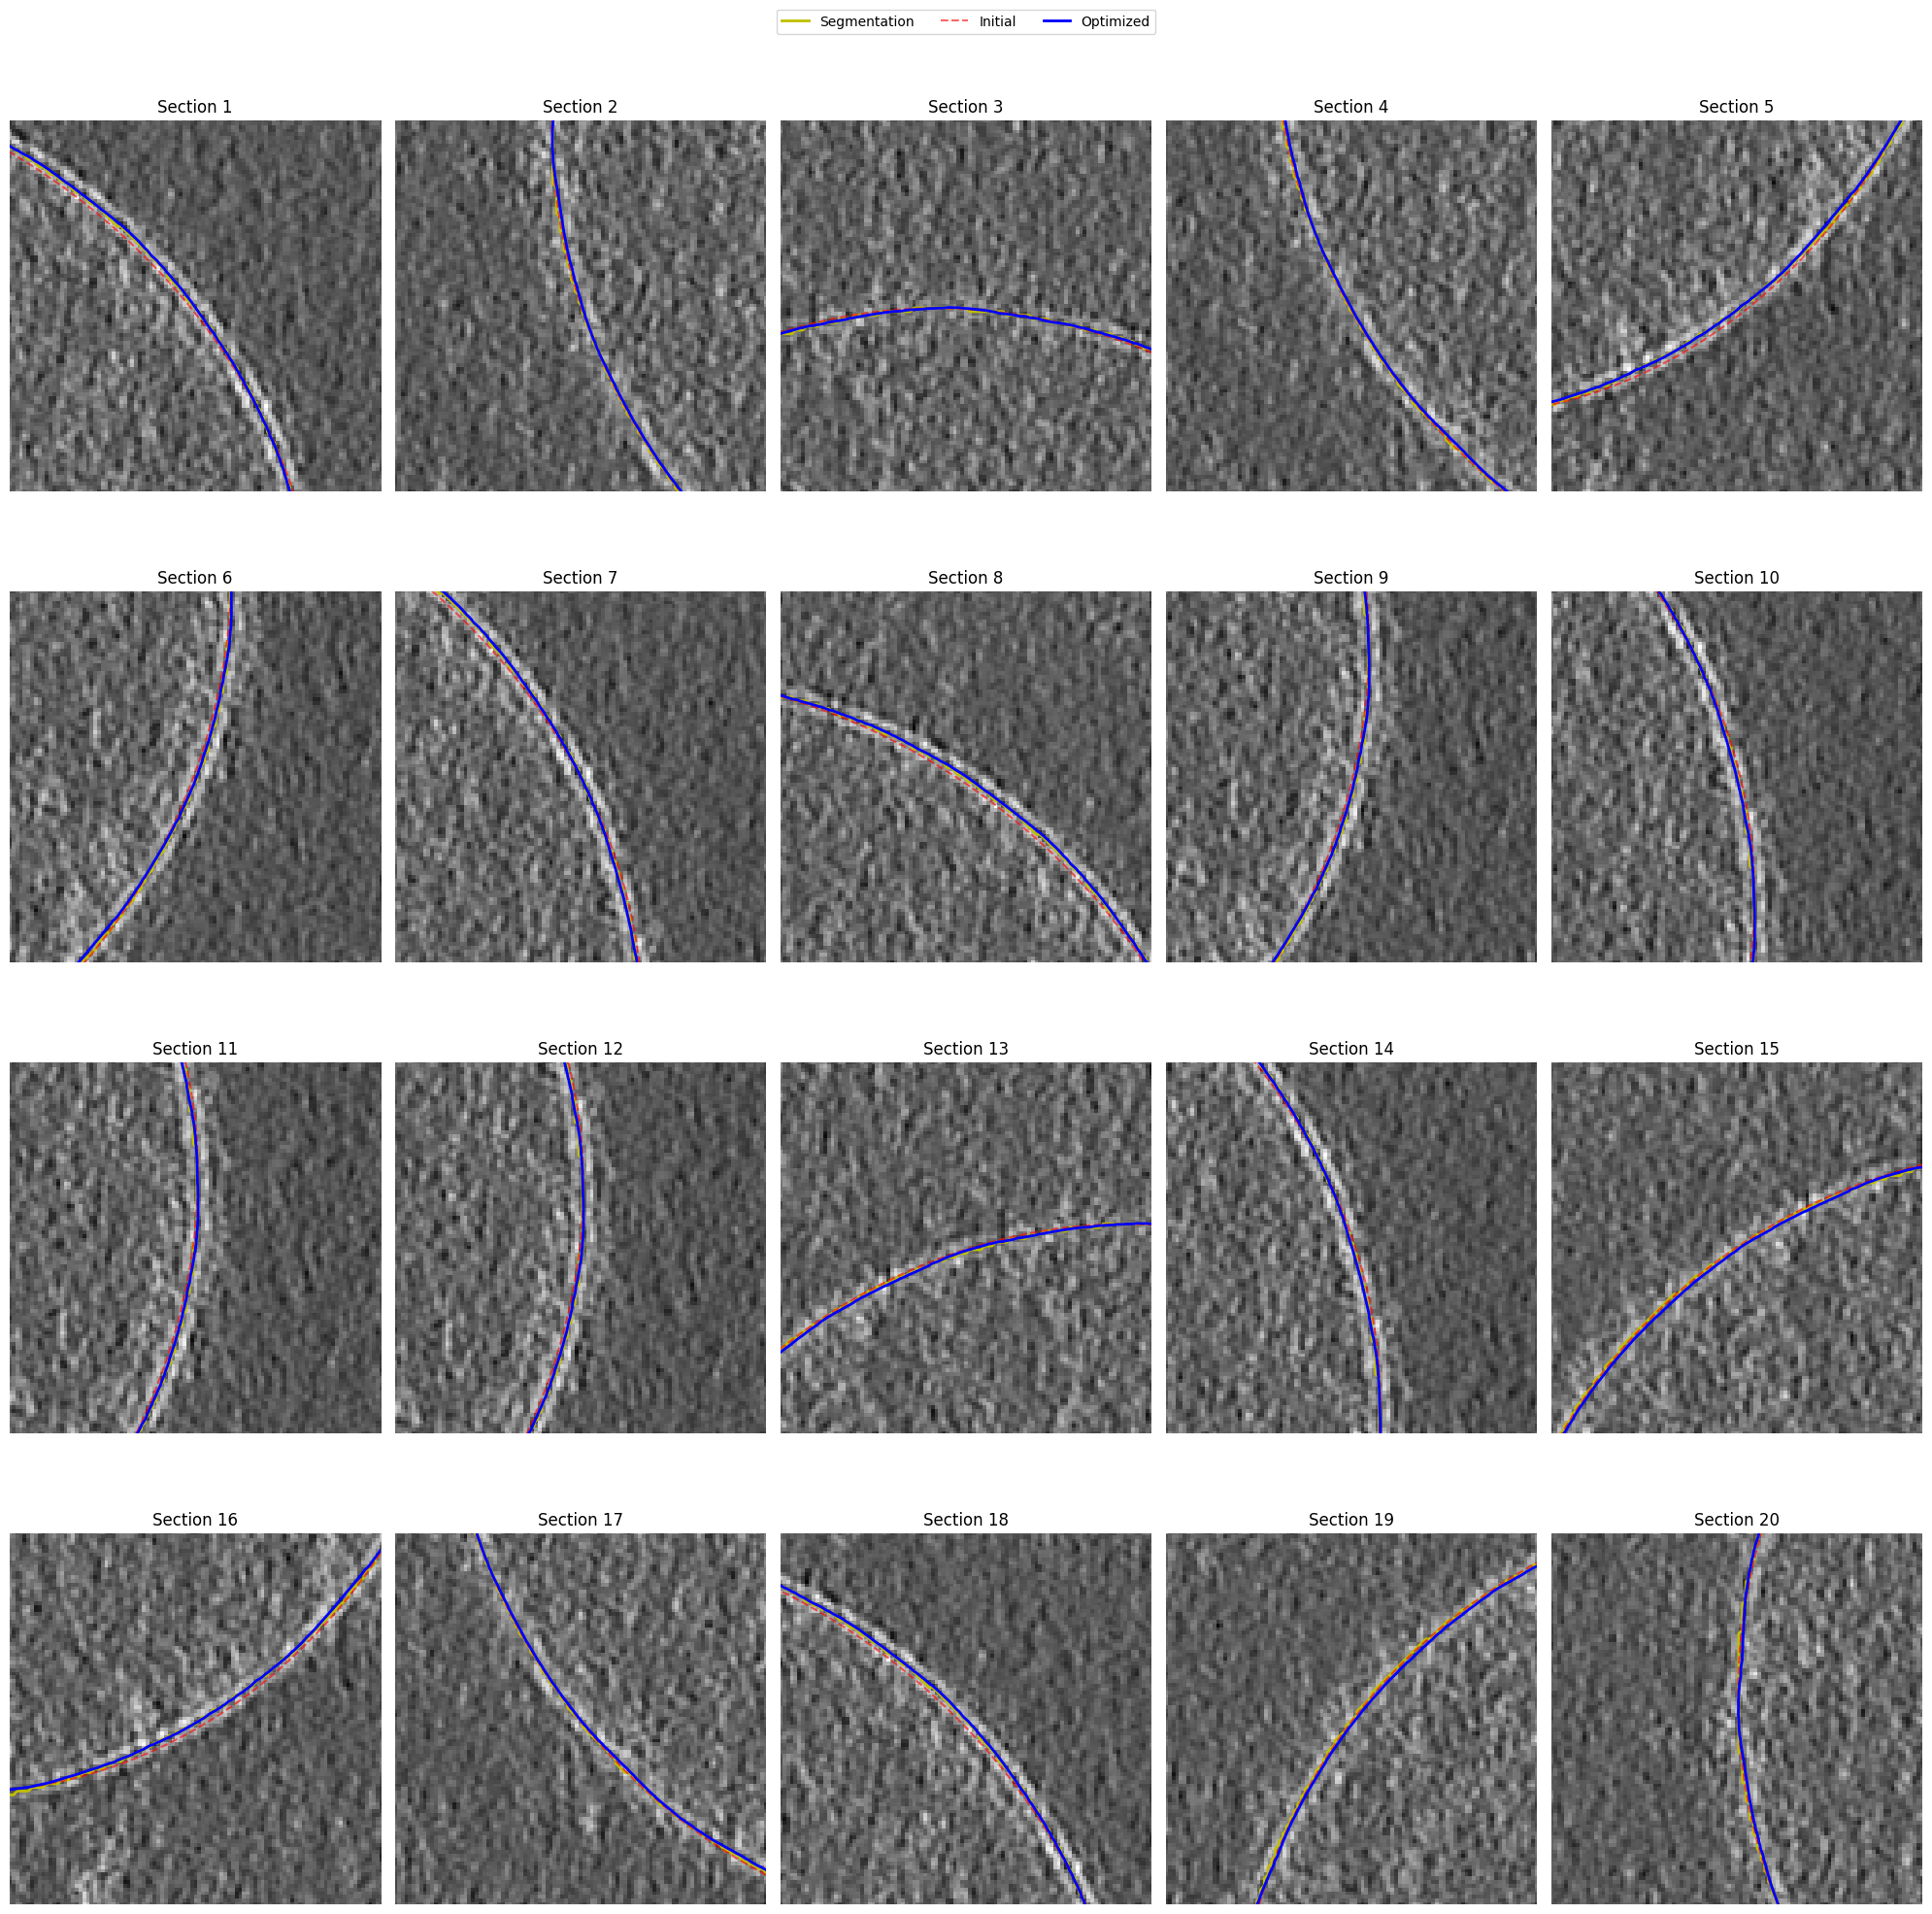

In [40]:
init_contour = contour_smoothed

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [41]:
template_params = refiner.template_model.get_params()

template_params

{'peak_dist': tensor(3.4244, device='cuda:0', grad_fn=<ExpBackward0>),
 'sigma': tensor(0.9462, device='cuda:0', grad_fn=<ExpBackward0>)}

In [44]:
updated_template_props = template_props.model_copy(
    update={
        "peak_dist": template_params["peak_dist"].detach().cpu().numpy(),
        "sigma": template_params["sigma"].detach().cpu().numpy(),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, amp=1.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2),
 TemplateProps(peak_dist=array(3.4243746, dtype=float32), sigma=array(0.94616264, dtype=float32), amp=1.0, num_samples=51, num_control_points=10, neural_hidden_dim=32, neural_num_layers=2))

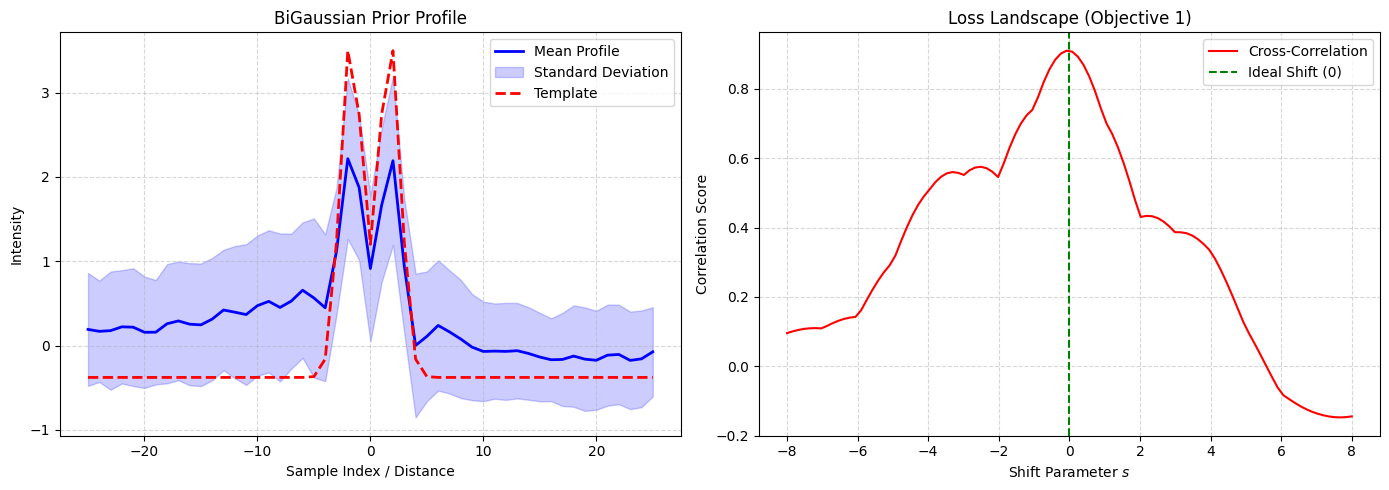

In [45]:
vis2d.plot_prior_and_landscape_from_contour(
    image_np, final_contour, sampling_props=sampling_props, template_props=updated_template_props
)

In [108]:
### TESTING THE BSPLINE REFINER ###

In [118]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

refiner = opt2d.BSplineContourRefiner(
    image=image_np,
    initial_contour=contour_smoothed,
    optimization_props=OptimizationProps(
        w_edge=10, w_laplacian=0.001, w_sigma_reg=0.01, w_template_shape=0.5, lr=0.1
    ),
    template_props=template_props,
    sampling_props=sampling_props,
    laplacian_window_size=2,
    optimize_template=True,
)
refiner.to(device)
print(f"Refiner initialized on {device}")
refiner.to(device)
print(f"Refiner initialized on {device}")

Refiner initialized on cuda
Refiner initialized on cuda


In [119]:
num_iterations = 500
history = []

print("Starting optimization...")
for i in tqdm(range(num_iterations)):
    # 1. Optimization Step
    metrics = refiner.step()
    history.append(metrics)


print("Optimization finished.")

Starting optimization...


  0%|          | 0/500 [00:00<?, ?it/s]

Optimization finished.


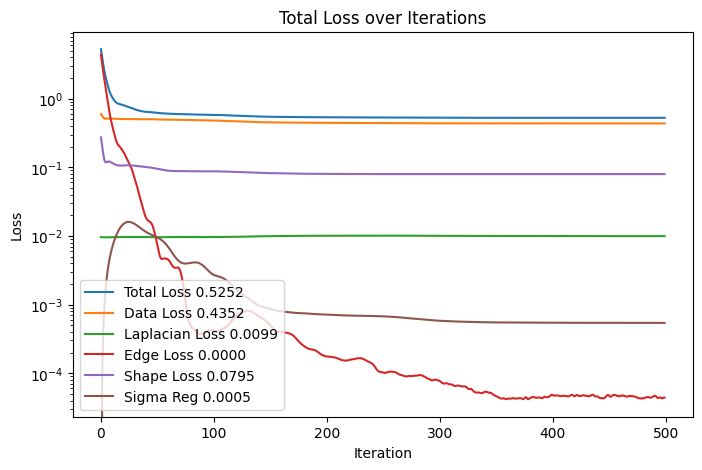

In [120]:
total_losses = [h["total_loss"] for h in history]
data_losses = [h["data_loss"] for h in history]
laplacian_losses = [h["laplacian_loss"] for h in history]
edge_losses = [h["edge_loss"] for h in history]
shape_losses = [h["shape_loss"] for h in history]
sigma_regs = [h["sigma_reg"] for h in history]

plt.figure(figsize=(8, 5))
plt.plot(total_losses, label=f"Total Loss {total_losses[-1]:.4f}")
plt.plot(data_losses, label=f"Data Loss {data_losses[-1]:.4f}")
plt.plot(laplacian_losses, label=f"Laplacian Loss {laplacian_losses[-1]:.4f}")

if refiner.optimize_template:
    plt.plot(edge_losses, label=f"Edge Loss {edge_losses[-1]:.4f}")
    plt.plot(shape_losses, label=f"Shape Loss {shape_losses[-1]:.4f}")
plt.plot(sigma_regs, label=f"Sigma Reg {sigma_regs[-1]:.4f}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Total Loss over Iterations")
plt.legend()
plt.show()

(20,)


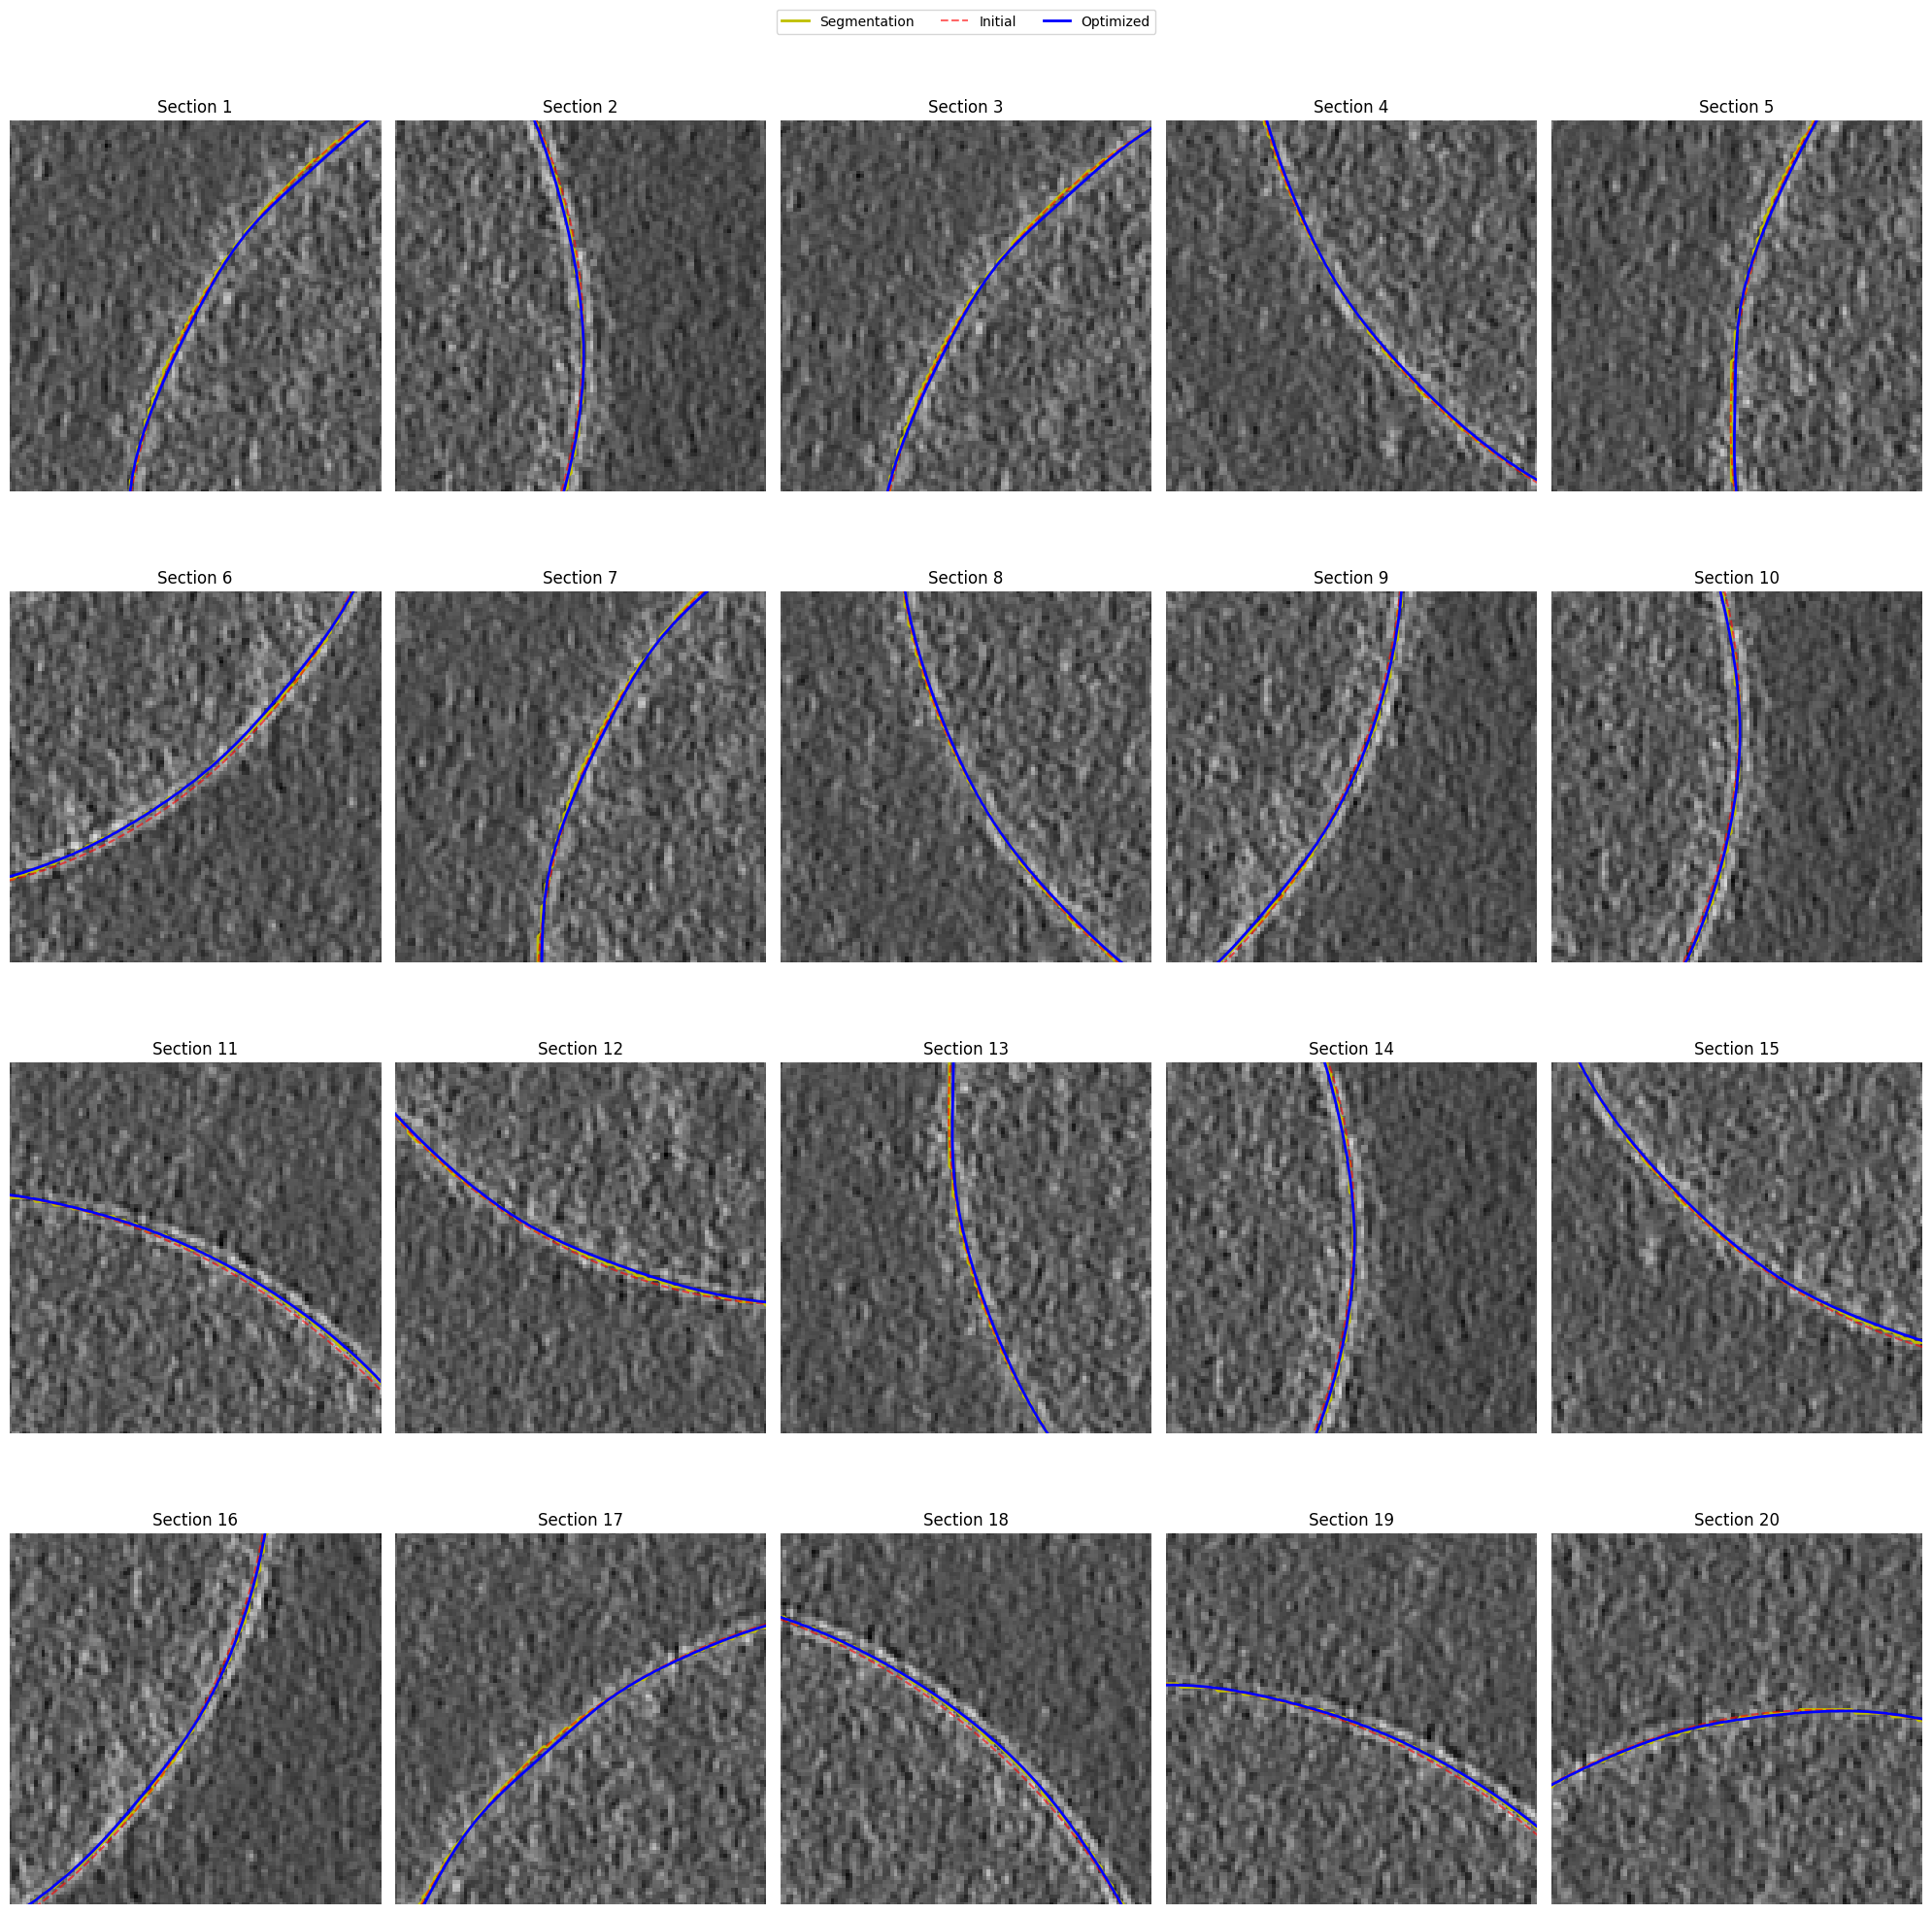

In [121]:
init_contour = contour_smoothed

num_crops = 20
crop_size = 100
half_size = crop_size // 2

# Ensure we have the final contour on CPU
final_contour = refiner.contour.detach().cpu().numpy()

# Select random indices along the final contour to center our crops
# We use the final contour to ensure we look at relevant areas
indices = random.sample(range(len(final_contour)), num_crops)

cols = 5
rows = np.ceil(num_crops / cols).astype(int)
fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
axes = axes.flatten()
# if num_crops == 1:
#    axes = [axes]
print(axes.shape)
H, W = image_np.shape

for i, idx in enumerate(indices):
    ax = axes[i]

    # Center of the crop (row, col) -> (y, x)
    cy, cx = final_contour[idx]

    # Define bounds (handling image edges)
    y_min = max(0, int(cy - half_size))
    y_max = min(H, int(cy + half_size))
    x_min = max(0, int(cx - half_size))
    x_max = min(W, int(cx + half_size))

    # Display the image
    ax.imshow(image_np, cmap="gray")

    # Plot contours
    # Note: plot takes (x, y) which corresponds to (col, row)
    ax.plot(contour_np[:, 1], contour_np[:, 0], "y-", linewidth=2, label="Segmentation")
    ax.plot(
        init_contour[:, 1], init_contour[:, 0], "r--", alpha=0.6, linewidth=1.5, label="Initial"
    )
    ax.plot(final_contour[:, 1], final_contour[:, 0], "b-", linewidth=2, label="Optimized")

    if "gt_contour_np" in locals() and len(gt_contour_np) > 0:
        ax.plot(gt_contour_np[:, 1], gt_contour_np[:, 0], "g:", alpha=0.8, linewidth=2, label="GT")

    # Zoom in by setting axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)  # Invert Y axis to match image origin (top-left)

    ax.set_title(f"Section {i + 1}")
    ax.axis("off")

# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

In [122]:
updated_template_props = template_props.model_copy(
    update={
        "peak_dist": np.exp(refiner.log_peak_dist.item()),
        "sigma": np.exp(refiner.log_sigma.item()),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, num_samples=51),
 TemplateProps(peak_dist=np.float64(3.4102469434782896), sigma=np.float64(0.9462808848352751), num_samples=51))

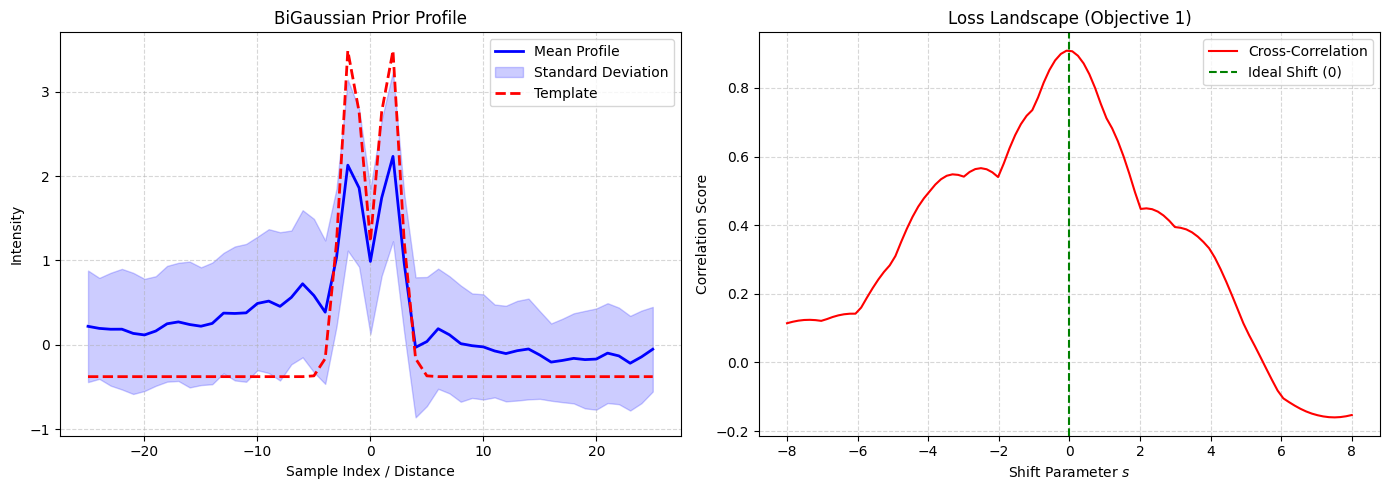

In [123]:
vis2d.plot_prior_and_landscape_from_contour(
    image_np,
    final_contour,
    sampling_props=sampling_props,
    template_props=updated_template_props,
)